In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/6temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/workstation-rental-price-tier-prediction/kaggle_ready_dataset/sample_submission.csv
/kaggle/input/competitions/workstation-rental-price-tier-prediction/kaggle_ready_dataset/train.csv
/kaggle/input/competitions/workstation-rental-price-tier-prediction/kaggle_ready_dataset/test.csv


In [2]:
#Today Topic: Problem Statement , some basic functions of pandas and Sklearn.
#Orientation of Notebook

#Work Flow -->   EDA --> Preprocessing --> Feature Engineering --> Model Building(HPT, Model Comparison) --> Error Analysis

# Data Loading

In [3]:
train=pd.read_csv('/kaggle/input/competitions/workstation-rental-price-tier-prediction/kaggle_ready_dataset/train.csv')
test=pd.read_csv('/kaggle/input/competitions/workstation-rental-price-tier-prediction/kaggle_ready_dataset/test.csv')
sub=pd.read_csv('/kaggle/input/competitions/workstation-rental-price-tier-prediction/kaggle_ready_dataset/sample_submission.csv')

In [4]:
# We have labels here --> Classes  
# This problem Statement is a Classification based Problem

In [5]:
# To check the shape of a file means no of observation(Rows) vs features(Columns)
print("=============================================")
print("============= Files Shapes ==================")
print(train.shape)
print(test.shape)
print(sub.shape)
print("==================END========================")

============= Files Shapes ==================
(279746, 60)
(114538, 59)
(114538, 2)
==================END========================


In [6]:
train.info()
# sparse feature and another is dense feature 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279746 entries, 0 to 279745
Data columns (total 60 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   space_id                      279746 non-null  int64  
 1   operator_ref                  279142 non-null  object 
 2   operator_platform_age_years   279142 non-null  float64
 3   operator_platform_age_months  279142 non-null  float64
 4   operator_active_years         279140 non-null  float64
 5   operator_active_months        279140 non-null  float64
 6   operator_class                279746 non-null  object 
 7   operator_certified            279142 non-null  object 
 8   operator_portfolio_size       279142 non-null  float64
 9   operator_has_avatar           279142 non-null  object 
 10  operator_id_verified          279142 non-null  object 
 11  zone                          279746 non-null  object 
 12  borough                       65295 non-null

In [7]:
numerical_columns= train.select_dtypes(include=['int64','float64']) # Hence it becomes numerical columns
categorical_columns= train.select_dtypes(include=['object']) # This is categorical columns

In [8]:
numerical_columns.columns

Index(['space_id', 'operator_platform_age_years',
       'operator_platform_age_months', 'operator_active_years',
       'operator_active_months', 'operator_portfolio_size', 'geo_lat',
       'geo_lon', 'max_seats', 'utility_rooms', 'zones', 'workstations',
       'min_term_days', 'max_term_days', 'min_term_floor', 'min_term_ceiling',
       'max_term_floor', 'max_term_ceiling', 'min_term_avg', 'max_term_avg',
       'open_slots_a', 'open_slots_b', 'open_slots_c', 'open_slots_d',
       'review_count', 'review_count_12m', 'review_count_30d', 'open_slots_e',
       'review_count_prev_yr', 'booked_load', 'score_overall',
       'score_accuracy', 'score_condition', 'score_onboarding',
       'score_support', 'score_access', 'score_value', 'operator_metro_units',
       'operator_metro_whole', 'operator_metro_private',
       'operator_metro_shared', 'reviews_per_month', 'price_tier'],
      dtype='object')

In [9]:
print(type(categorical_columns))

<class 'pandas.core.frame.DataFrame'>


In [10]:
categorical_columns.columns

Index(['operator_ref', 'operator_class', 'operator_certified',
       'operator_has_avatar', 'operator_id_verified', 'zone', 'borough',
       'space_class', 'access_type', 'facilities', 'snapshot_start_date',
       'snapshot_end_date', 'bookable', 'first_review_date',
       'last_review_date', 'compliance_status', 'metro'],
      dtype='object')

In [11]:
print("++++++++++++++++++++++++++++")
print("===== Numerical Columns ======")
print(len(numerical_columns.columns))
print("===== Categorical Columns ======")
print(len(categorical_columns.columns))

++++++++++++++++++++++++++++
===== Numerical Columns ======
43
===== Categorical Columns ======
17


## EDA

In [ ]:
#Lets do Missing value count -- Nan values
#All unqiue values
#Data Visualization 
#Correlation Matrix

#### Descriptive Statistics

In [13]:
columns=numerical_columns.columns.tolist()
train[columns].describe().T

,count,mean,std,min,25%,50%,75%,max
space_id,279746.0,139872.500000,8.075586e+04,0.0000,69936.2500,139872.5000,209808.7500,2.797450e+05
operator_platform_age_years,279142.0,6.794735,4.187652e+00,0.0000,3.0000,7.0000,10.0000,1.700000e+01
operator_platform_age_months,279142.0,5.453275,3.489590e+00,0.0000,2.0000,5.0000,9.0000,1.100000e+01
operator_active_years,279140.0,5.083295,4.040029e+00,0.0000,2.0000,4.0000,8.0000,1.500000e+01
operator_active_months,279140.0,5.298635,3.480848e+00,0.0000,2.0000,5.0000,8.0000,1.100000e+01
operator_portfolio_size,279142.0,49.472043,3.327522e+02,0.0000,1.0000,4.0000,19.0000,5.978000e+03
geo_lat,279746.0,77.766908,3.751376e+01,-4.8180,68.0415,94.6230,100.9410,1.117680e+02
geo_lon,279746.0,-35.144810,5.717006e+01,-123.7498,-76.5598,-31.1326,-21.2656,8.704520e+01
max_seats,279746.0,3.627312,2.277564e+00,1.0000,2.0000,3.0000,4.0000,1.600000e+01
utility_rooms,249847.0,1.358645,8.063074e-01,0.5000,1.0000,1.0000,1.5000,5.000000e+01


#### Checking Unique Values in Each Column

In [15]:
for columns in train.columns:
    print("======================")
    print(f"Column Name of Traning Data {columns} : {train[columns].nunique()}")

#Space_id is basically a identifier
#Facilities also has a good no of unique values which means the values are diverse
#operator_ref also has a good no of unqiue values

Column Name of Traning Data space_id : 279746
Column Name of Traning Data operator_ref : 41903
Column Name of Traning Data operator_platform_age_years : 18
Column Name of Traning Data operator_platform_age_months : 12
Column Name of Traning Data operator_active_years : 16
Column Name of Traning Data operator_active_months : 12
Column Name of Traning Data operator_class : 3
Column Name of Traning Data operator_certified : 2
Column Name of Traning Data operator_portfolio_size : 328
Column Name of Traning Data operator_has_avatar : 2
Column Name of Traning Data operator_id_verified : 2
Column Name of Traning Data zone : 1380
Column Name of Traning Data borough : 55
Column Name of Traning Data geo_lat : 632
Column Name of Traning Data geo_lon : 949
Column Name of Traning Data space_class : 131
Column Name of Traning Data access_type : 4
Column Name of Traning Data max_seats : 16
Column Name of Traning Data utility_rooms : 43
Column Name of Traning Data zones : 38
Column Name of Traning Dat

#### Checking empty values

In [18]:
nan_column_fields= list()
for miss in train.columns :
    print(f"Missing Value Count of : {miss} features : {train[miss].isna().sum()}")
    if train[miss].isna().sum() > 0:
        nan_column_fields.append(miss)
print(f"Columns having empty values are : {nan_column_fields}")

Missing Value Count of : space_id features : 0
Missing Value Count of : operator_ref features : 604
Missing Value Count of : operator_platform_age_years features : 604
Missing Value Count of : operator_platform_age_months features : 604
Missing Value Count of : operator_active_years features : 606
Missing Value Count of : operator_active_months features : 606
Missing Value Count of : operator_class features : 0
Missing Value Count of : operator_certified features : 604
Missing Value Count of : operator_portfolio_size features : 604
Missing Value Count of : operator_has_avatar features : 604
Missing Value Count of : operator_id_verified features : 604
Missing Value Count of : zone features : 0
Missing Value Count of : borough features : 214451
Missing Value Count of : geo_lat features : 0
Missing Value Count of : geo_lon features : 0
Missing Value Count of : space_class features : 0
Missing Value Count of : access_type features : 0
Missing Value Count of : max_seats features : 0
Missing

#### Correlation with the Target Value

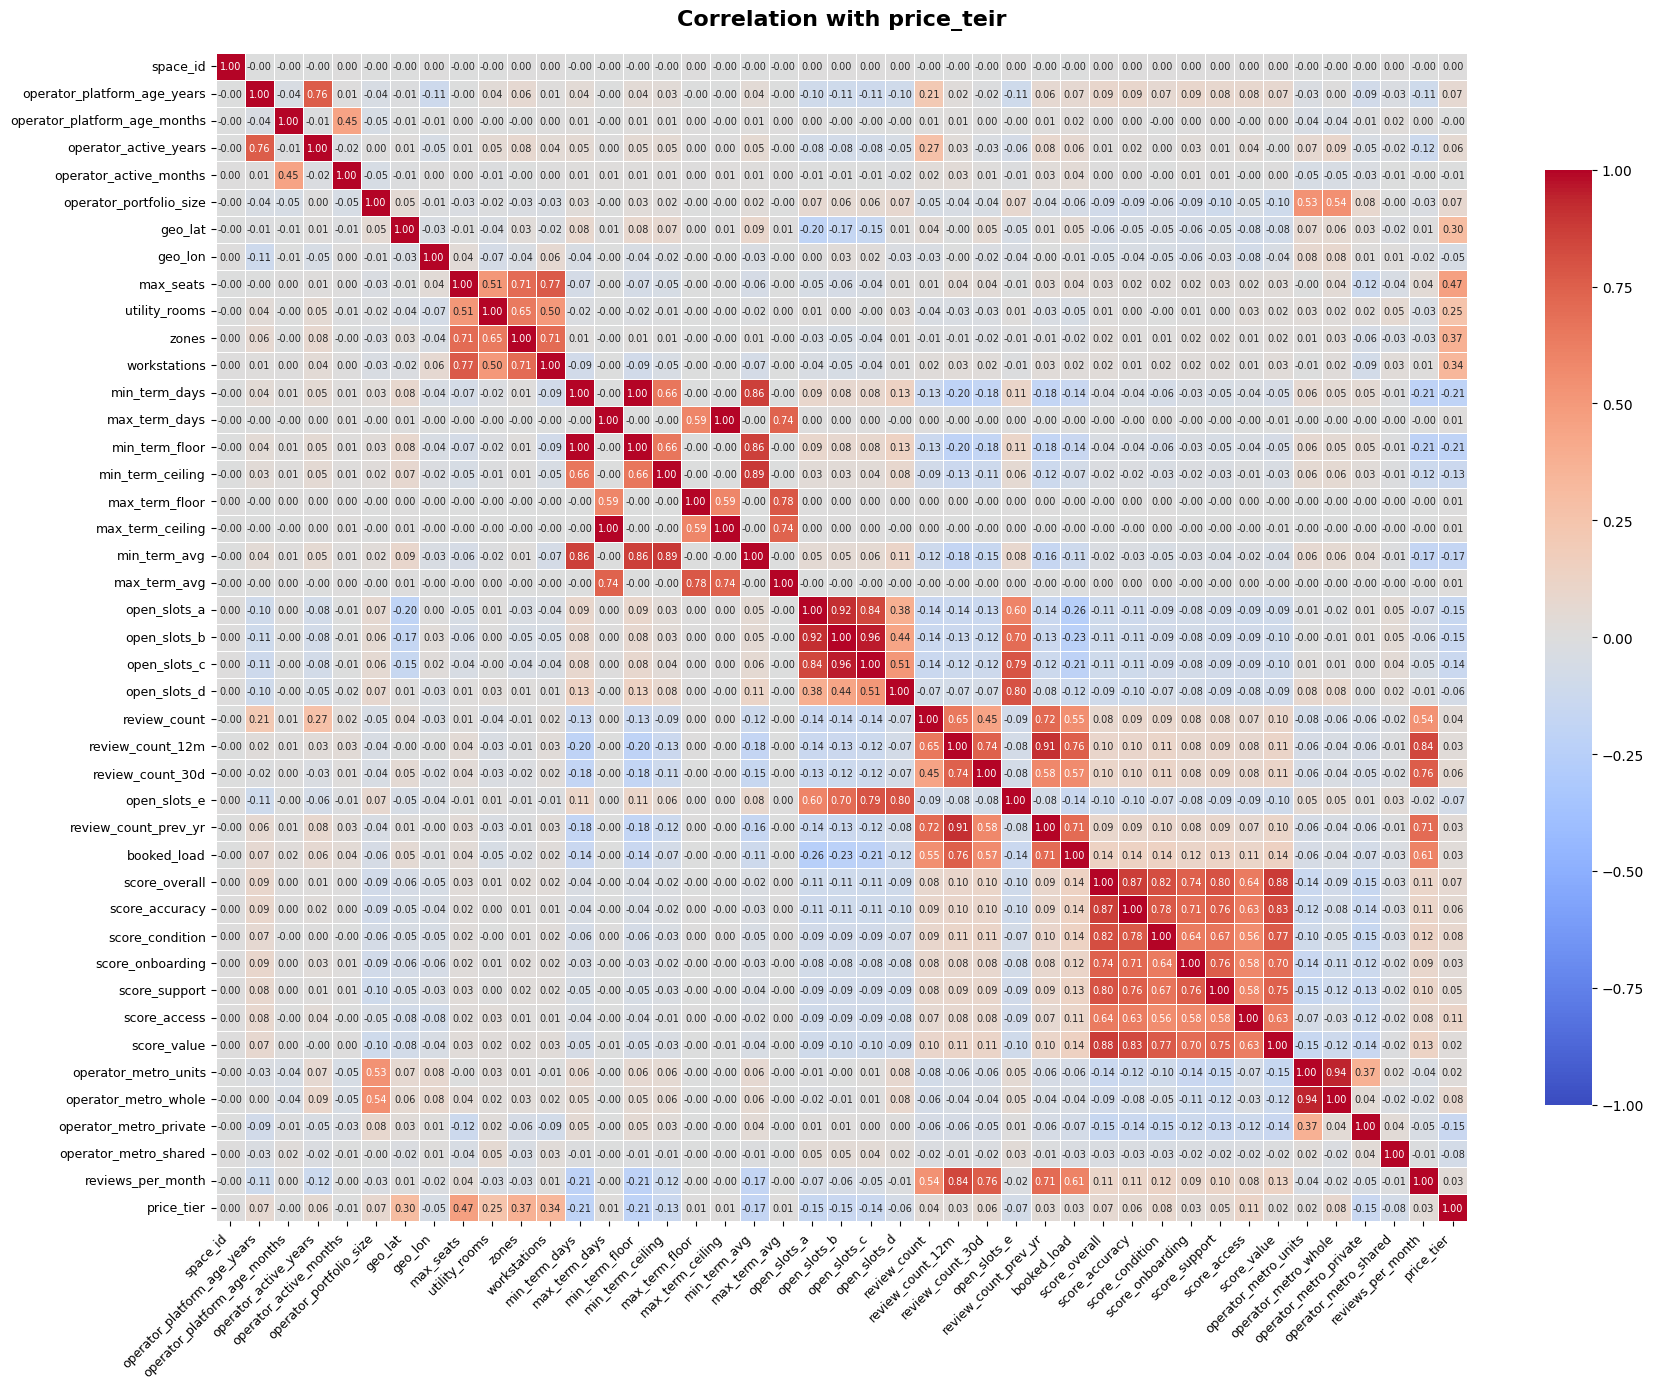

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(18,14))

corr_matrix = numerical_columns.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    cbar_kws={"shrink" : 0.8}
    
)

plt.xticks(rotation=45, ha="right" , fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title("Correlation with price_teir", fontsize=16,pad=20,weight="bold")

plt.tight_layout()

plt.show()

#corr(x,x) = 1 

#### Check Outliers

In [21]:
numerical_columns.columns

Index(['space_id', 'operator_platform_age_years',
       'operator_platform_age_months', 'operator_active_years',
       'operator_active_months', 'operator_portfolio_size', 'geo_lat',
       'geo_lon', 'max_seats', 'utility_rooms', 'zones', 'workstations',
       'min_term_days', 'max_term_days', 'min_term_floor', 'min_term_ceiling',
       'max_term_floor', 'max_term_ceiling', 'min_term_avg', 'max_term_avg',
       'open_slots_a', 'open_slots_b', 'open_slots_c', 'open_slots_d',
       'review_count', 'review_count_12m', 'review_count_30d', 'open_slots_e',
       'review_count_prev_yr', 'booked_load', 'score_overall',
       'score_accuracy', 'score_condition', 'score_onboarding',
       'score_support', 'score_access', 'score_value', 'operator_metro_units',
       'operator_metro_whole', 'operator_metro_private',
       'operator_metro_shared', 'reviews_per_month', 'price_tier'],
      dtype='object')

In [ ]:
### --> score --->  [-ve]                       [0]                          [+ve --> 1,2, ... infinity]
#                           [-300]      [8,9,12,20]   [100]

In [22]:
# Using IQR method

q1_x,q3_x=train['operator_platform_age_years'].quantile(0.25) , train['operator_platform_age_years'].quantile(0.75)

iqr_x=q3_x - q1_x

lower_x,upper_x= q1_x - 1.5 * iqr_x, q3_x + 1.5 * iqr_x

print(lower_x)
print(upper_x)

-7.5
20.5


In [23]:
lower_points= (train['operator_platform_age_years'] < lower_x).sum()
upper_points= (train['operator_platform_age_years'] > upper_x).sum()
print(f"Low outliers : {lower_points}")
print(f"High outliers : {upper_points}")

Low outliers : 0
High outliers : 0


In [24]:
def calculate_outliers(data):
    q1_x,q3_x=data.quantile(0.25) , data.quantile(0.75)

    iqr_x=q3_x - q1_x

    lower_x,upper_x= q1_x - 1.5 * iqr_x, q3_x + 1.5 * iqr_x

    return lower_x,upper_x

def get_outlier_points(lp,up,data):
    lower_points= (data < lp).sum()
    upper_points= (data > up).sum()
    return lower_points,upper_points

In [25]:
for i in numerical_columns.columns:
    print("==========================")
    lower_x,upper_x=calculate_outliers(train[i])
    lp,up=get_outlier_points(lower_x,upper_x,train[i])

    print(f"Feature Name : {i}")
    print(f"Lower Threshold Points : {lp}")
    print(f"Upper Threshold Points : {up}")

Feature Name : space_id
Lower Threshold Points : 0
Upper Threshold Points : 0
Feature Name : operator_platform_age_years
Lower Threshold Points : 0
Upper Threshold Points : 0
Feature Name : operator_platform_age_months
Lower Threshold Points : 0
Upper Threshold Points : 0
Feature Name : operator_active_years
Lower Threshold Points : 0
Upper Threshold Points : 0
Feature Name : operator_active_months
Lower Threshold Points : 0
Upper Threshold Points : 0
Feature Name : operator_portfolio_size
Lower Threshold Points : 0
Upper Threshold Points : 39784
Feature Name : geo_lat
Lower Threshold Points : 51250
Upper Threshold Points : 0
Feature Name : geo_lon
Lower Threshold Points : 0
Upper Threshold Points : 29033
Feature Name : max_seats
Lower Threshold Points : 0
Upper Threshold Points : 18102
Feature Name : utility_rooms
Lower Threshold Points : 0
Upper Threshold Points : 18474
Feature Name : zones
Lower Threshold Points : 0
Upper Threshold Points : 12099
Feature Name : workstations
Lower Th

#### Box Plot for Outliers

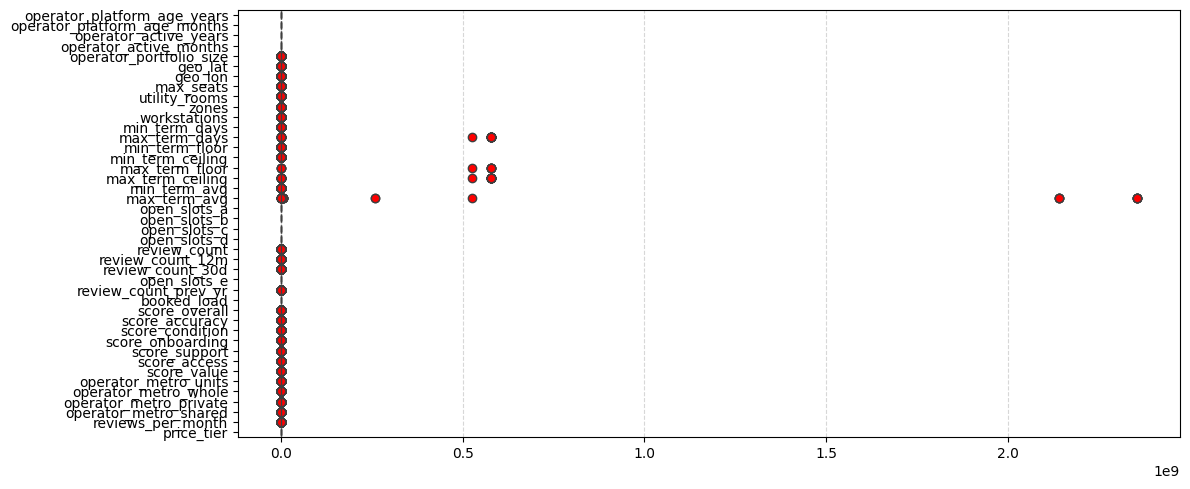

In [26]:
plt.figure(figsize=(12,5))
columns=['operator_platform_age_years',
       'operator_platform_age_months', 'operator_active_years',
       'operator_active_months', 'operator_portfolio_size', 'geo_lat',
       'geo_lon', 'max_seats', 'utility_rooms', 'zones', 'workstations',
       'min_term_days', 'max_term_days', 'min_term_floor', 'min_term_ceiling',
       'max_term_floor', 'max_term_ceiling', 'min_term_avg', 'max_term_avg',
       'open_slots_a', 'open_slots_b', 'open_slots_c', 'open_slots_d',
       'review_count', 'review_count_12m', 'review_count_30d', 'open_slots_e',
       'review_count_prev_yr', 'booked_load', 'score_overall',
       'score_accuracy', 'score_condition', 'score_onboarding',
       'score_support', 'score_access', 'score_value', 'operator_metro_units',
       'operator_metro_whole', 'operator_metro_private',
       'operator_metro_shared', 'reviews_per_month', 'price_tier']

sns.boxplot(
    data=train[columns],
    orient='h',
    color="skyblue",
    flierprops={'markerfacecolor' : 'red', 'marker' : 'o'}
)

plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show

#### Scatter plot

<Axes: xlabel='max_seats', ylabel='price_tier'>

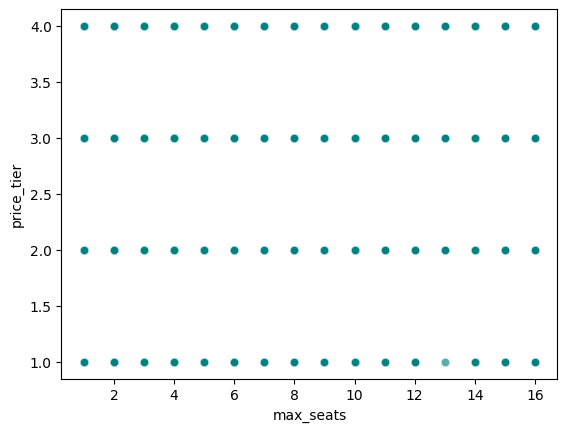

In [27]:
#max_seats was having the high correlation.
sns.scatterplot(
    data=train,
    x="max_seats",
    y="price_tier",
    alpha=0.4,
    color="teal",
    edgecolor="w",
    linewidth=0.5
)

#### Class Imbalance

In [28]:
train['price_tier'].value_counts() # No class Imbalance
#If class imbalance was there what metric we use ? --> F1 score,Accuracy Does not give the correctness as compared to F1
#1 --> 30k 2--> 60K . Here the Model will take biased decision 
#In such cases what we can do ?
#We will use resampling to increase the training set of 1 to 60k

price_tier
2    81530
4    70488
1    66889
3    60839
Name: count, dtype: int64

In [32]:
train['operator_platform_age_years'].value_counts().sort_values(ascending=True)

operator_platform_age_years
17.0       78
16.0      530
15.0     2421
14.0     7181
5.0     10943
13.0    11641
4.0     15829
6.0     15957
0.0     16471
8.0     17819
12.0    18369
7.0     19989
3.0     21596
1.0     21716
9.0     22884
11.0    23160
2.0     23846
10.0    28712
Name: count, dtype: int64

In [33]:
print(train['geo_lat'].value_counts())

geo_lat
 107.9745    6006
 10.9770     5792
 98.5650     5531
 107.9610    5444
 10.9905     5355
             ... 
 86.9955        1
 88.6020        1
 98.2275        1
-3.1170         1
 90.3840        1
Name: count, Length: 632, dtype: int64


In [35]:
#The maximum value of lat is 90
print(train[train['geo_lat'].abs() > 90]['geo_lat'].count()) # Higly Suspicious
print(train[train['geo_lon'].abs() > 180]['geo_lon'].count()) 

170368
0


## Preprocessing

## Feature Engineering

## Model Building

## Hyper Parametric Tunning

## Model Comparision

## Error Analysis

## Observation

## Submission

In [ ]:
sub.to_csv('submission.csv',index=False)
print("submission.csv saved succesfully")

In [ ]:
val=pd.read_csv('/kaggle/working/submission.csv')
val.shape

In [ ]:
test.shape

## MileStone - 1

In [ ]:
# Dummy codes 
# line 1
# line 2 
# line 3
# line 4
# .....................
# Q1. What is the size of Train.csv file
#train.shape

## MileStone - 2

In [ ]:
# 1
# 2
# 3
# 4
# 5
# 6